<a href="https://colab.research.google.com/github/aravinth-xuno/fraud-detection-notebook/blob/main/high_volume_transaction_anomaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/Shareddrives/transaction-training-set/dataset/txn_prod_2026-02-11.csv", low_memory=False)

### Display DataFrame Shape
This cell shows the number of rows and columns in the `df` DataFrame.

In [ ]:
df.shape

(177026, 29)

### Convert 'INITIATED_AT' to Datetime
This cell converts the `INITIATED_AT` column to a datetime object, which is essential for time-based filtering and calculations.

In [ ]:
df['INITIATED_AT'] = pd.to_datetime(df['INITIATED_AT'], format="ISO8601", utc=True)

### Filter Transactions from 2019 Onwards
This cell creates a new DataFrame `txn_before_2019` containing only transactions that occurred from the year 2019 onwards.

In [ ]:
txn_before_2019 = df[df['INITIATED_AT'].dt.year >= 2019]

### Display Filtered DataFrame Shape
This cell shows the number of rows and columns in the `txn_before_2019` DataFrame after filtering.

In [ ]:
txn_before_2019.shape

(119420, 29)

### Exclude a Specific Active User
This cell defines a specific user ID (`active_user`) and then creates a new DataFrame `exclude_active_user` by removing all transactions associated with that user.

In [ ]:
active_user = "678f68630f6bb45cbf0af930"
exclude_active_user = txn_before_2019[txn_before_2019['USER_ID'] != active_user]

### Display Shape After Excluding Active User
This cell shows the number of rows and columns in the `exclude_active_user` DataFrame after removing a specific user's transactions.

In [ ]:
exclude_active_user.shape

(118625, 29)

### Identify Users with More Than 10 Recent Transactions
This cell calculates the number of transactions per user from `exclude_active_user` and identifies users who have made more than 10 transactions. It then prints the list of these users.

In [ ]:
user_transaction_counts = exclude_active_user.groupby('USER_ID').size().reset_index(name='transaction_count')
users_more_than_10_transactions = user_transaction_counts[user_transaction_counts['transaction_count'] > 10]

print("Users with more than 10 transactions:")
print(users_more_than_10_transactions)

Users with more than 10 transactions:
     USER_ID  transaction_count
11     10166                 37
12     10178                 12
18     10213                 21
21      1027                 43
25     10302                 14
...      ...                ...
8727    9796                 52
8729     981                 18
8736    9884                 12
8743    9958                 17
8748     999                 16

[2991 rows x 2 columns]


### Count Users with More Than 10 Transactions
This cell prints the total number of unique users who have performed more than 10 transactions.

In [ ]:
print(f"Number of Users with more than 10 transactions {len(users_more_than_10_transactions)}")

Number of Users with more than 10 transactions 2991


### Filter Transactions Since January 2025
This cell creates `df_recent_transactions` by filtering `exclude_active_user` to include only transactions that occurred from January 1, 2025, onwards.

In [ ]:
df_recent_transactions = exclude_active_user[
    exclude_active_user['INITIATED_AT'] >= '2025-01-01'
]

### Display Shape of Recent Transactions
This cell shows the number of rows and columns in the `df_recent_transactions` DataFrame.

In [ ]:
df_recent_transactions.shape

(18396, 29)

### Filter Recent Transactions by High-Volume Users
This cell filters `df_recent_transactions` to include only those transactions made by users who were identified as having more than 10 transactions in the previous steps. This helps focus on potentially active or high-velocity users.

In [ ]:
high_velocity_users = df_recent_transactions[df_recent_transactions['USER_ID'].isin(users_more_than_10_transactions['USER_ID'])]

### Count Unique Users in Recent Transactions
This cell calculates and prints the number of unique user IDs present in the `df_recent_transactions` DataFrame.

In [ ]:
transacted_user = high_velocity_users['USER_ID'].nunique()
print(f"Number of User perform transaction: {transacted_user}")

Number of User perform transaction: 1707


### Display Shape of dataframe after apply all filter
This cell shows the number of rows and columns in the `high_velocity_users` DataFrame.

In [ ]:
high_velocity_users.to_csv('training_dataset_high_velocity_users.csv', index = False)

In [ ]:
high_velocity_users.shape

(15440, 29)

### Feature Engineering for High Velocity Transactions
This cell sorts the DataFrame by user and time, then calculates various velocity features using rolling windows: transaction counts within the last 1 hour, the 24 hours prior to the last hour, and the 30 days prior to the last 25 hours. These features are crucial for identifying unusual transaction patterns.

In [ ]:
train_df = high_velocity_users.copy()

# 1. Pre-processing: Convert to datetime and sort
# Sorting is critical so the .values assignment aligns correctly

train_df = train_df.sort_values(by=['USER_ID', 'INITIATED_AT']).reset_index(drop=True)

# 2. Define the rolling windows for the raw counts
# We use a helper function or dictionary to keep the code clean
grouped = train_df.groupby('USER_ID')

# Calculation: Recent 1 Hour
# Window: [T, T - 1h]
train_df['cnt_1h'] = grouped.rolling('1h', on='INITIATED_AT')['TRANSACTION_KEY'].count().values - 1

# Calculation: Total 25 Hours (to derive the 24h block ending 1h ago)
# Window: [T, T - 25h]
train_df['cnt_total_25h'] = grouped.rolling('25h', on='INITIATED_AT')['TRANSACTION_KEY'].count().values - 1

train_df['last_24hour_count'] = grouped.rolling('24h', on='INITIATED_AT')['TRANSACTION_KEY'].count().values - 1

# Calculation: Total 31 Days + 1 Hour (to derive the 30d block ending 25h ago)
# Window: [T, T - 745h]
train_df['cnt_total_31d'] = grouped.rolling('31D', on='INITIATED_AT')['TRANSACTION_KEY'].count().values - 1

# 3. Final Feature Transformation (Isolating the specific blocks)
# Feature 1: Current activity
train_df['last_1hour_count'] = train_df['cnt_1h']

# Feature 2: 24h window ending 1 hour ago (Total 25h - Recent 1h)
train_df['last_24hour_count_shifted'] = train_df['cnt_total_25h'] - train_df['cnt_1h']

# Feature 3: 30d window ending 25 hours ago (Total 31d 1h - Recent 25h)
train_df['last_30days_count_shifted'] = train_df['cnt_total_31d'] - train_df['last_24hour_count']

# 4. Clean up intermediate columns
train_df.drop(columns=['cnt_total_25h', 'cnt_total_31d'], inplace=True)

# Display the result
print(train_df[['USER_ID', 'INITIATED_AT', 'last_1hour_count', 'last_24hour_count_shifted', 'last_30days_count_shifted']].tail())

                        USER_ID                     INITIATED_AT  \
15435  6924b0c35d1509496b7b9efd 2026-01-09 16:44:27.307000+00:00   
15436  6924b0c35d1509496b7b9efd 2026-01-16 22:58:17.555000+00:00   
15437  6924b0c35d1509496b7b9efd 2026-01-21 16:54:36.324000+00:00   
15438  6924b0c35d1509496b7b9efd 2026-01-29 18:07:26.063000+00:00   
15439  6924b0c35d1509496b7b9efd 2026-01-31 22:45:47.389000+00:00   

       last_1hour_count  last_24hour_count_shifted  last_30days_count_shifted  
15435               0.0                        0.0                        3.0  
15436               0.0                        0.0                        3.0  
15437               0.0                        0.0                        4.0  
15438               0.0                        0.0                        4.0  
15439               0.0                        0.0                        5.0  


### Calculate Ratio Features
This cell derives ratio-based features from the previously calculated velocity counts. These ratios help in normalizing transaction volumes and identifying relative changes in activity, which can be indicative of anomalies.

In [ ]:
train_df['ratio_1hr_24hr'] = train_df['last_1hour_count'] / (train_df['last_24hour_count_shifted'] + 1e-9)
train_df['ratio_24hr_30day'] = train_df['last_24hour_count'] / (train_df['last_30days_count_shifted'] + 1e-9)

### Pair Plot of Ratio Features
This cell generates a pair plot using `seaborn` to visualize the distributions and relationships between the newly created ratio features (`ratio_1hr_24hr`, `ratio_24hr_30day`) in the `train_df` DataFrame. The `diag_kind='kde'` displays kernel density estimates on the diagonal.

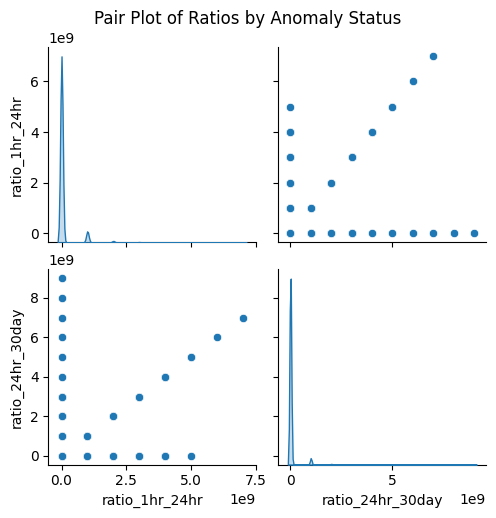

In [ ]:
# df1 contains the ratio features and the 'anomaly' column
sns.pairplot(train_df, vars=['ratio_1hr_24hr', 'ratio_24hr_30day'], diag_kind='kde')
plt.suptitle('Pair Plot of Ratios by Anomaly Status', y=1.02) # Adjust suptitle position
plt.show()

### Define Training and Ratio Features
This cell defines lists of column names that will be used for training the anomaly detection models (`training_features`) and specifically for scaling (`ratio_features`).

In [ ]:
training_features = [
    'last_1hour_count', 'last_24hour_count_shifted', 'last_30days_count_shifted',
    'ratio_1hr_24hr', 'ratio_24hr_30day'
]
ratio_features = [
    'ratio_1hr_24hr', 'ratio_24hr_30day'
]

### Display Training Features Shape
This cell shows the dimensions (rows, columns) of the DataFrame slice used for training the model. Note: `train_df` needs to be defined.

In [ ]:
train_df[training_features].shape

(15440, 5)

### Initialize and Fit MinMaxScaler
This cell initializes a `MinMaxScaler` from scikit-learn and fits it to the `ratio_features` of the `train_df` DataFrame. Fitting the scaler calculates the minimum and maximum values for each feature, which are then used for scaling. Note: `train_df` needs to be defined.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(train_df[ratio_features])

min_values = scaler.data_min_
max_values = scaler.data_max_

print("Training Min:", min_values)
print("Training Max:", max_values)

Training Min: [0. 0.]
Training Max: [7.e+09 9.e+09]


### Apply Min-Max Scaling to Ratio Features
This cell creates a copy of `train_df` named `df_scaled` and then applies the previously fitted `MinMaxScaler` to transform the `ratio_features`. This scales the feature values to a range between 0 and 1.

In [ ]:
df_scaled = train_df.copy()
df_scaled[ratio_features] = scaler.transform(train_df[ratio_features])

### Train Isolation Forest Model
This cell initializes and trains a new Isolation Forest model (`model`) using the *scaled* `training_features` from `df_scaled`. Scaling can sometimes improve model performance by preventing features with larger numerical ranges from dominating the learning process.

In [ ]:
from sklearn.ensemble import IsolationForest
model = IsolationForest(contamination=0.001)
model.fit(df_scaled[training_features])

IsolationForest(contamination=0.001)

### Predict Anomalies and Count
This cell uses the Isolation Forest model trained with scaled data (`model`) to predict anomalies on `train_df`. It then counts and prints the number of detected outliers and non-fraudulent transactions. Note: `train_df` needs to be defined.

In [ ]:
train_df['anomaly'] = model.predict(train_df[training_features])
outliers = (train_df['anomaly'] == -1).sum()
print(f"Number of detected outliers: {outliers}")
nonfraud = (train_df['anomaly'] == 1).sum()
print(f"Number of detected nonfraud: {nonfraud}")

Number of detected outliers: 93
Number of detected nonfraud: 15347


### Save Scaled Model and Scaler
This cell saves both the Isolation Forest model trained with scaled features (`model`) and the `MinMaxScaler` (`scaler`) to separate pickle files. This allows for consistent scaling and model prediction in future uses.

In [ ]:
import pickle

with open("scaledmodel_con0.001_activerecords.pkl", "wb") as f:
    pickle.dump(model, f)

with open("ratio_minmax_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)


### Predict on Sample Data
This cell uses the scaled Isolation Forest model (`model`) to make predictions on the same sample data points used previously. It's important to note that the input sample data here is *not* scaled, which might lead to unexpected results if the model was trained on scaled data. The sample data should ideally also be scaled before prediction if the model expects scaled input.

In [ ]:
new_data = pd.DataFrame([
    [0,0,1,0,0],
    [1,1,2,1,0.5],
    [2,3,8,0.66,0.37],
    [3,3,3,1,1],
    [5,5,6,1,0.83],
    [7,7,10,1,0.7],
    [1,1,18,1,0.05],
    [1,0,0,1e9,1e9]
], columns = training_features)

In [ ]:
new_data[ratio_features] = scaler.transform(new_data[ratio_features])
predict = model.predict(new_data)
predict

array([1, 1, 1, 1, 1, 1, 1, 1])

### Define Expected Predictions
This cell defines a list of expected anomaly predictions for the sample data when using the scaled model, similar to the `expected` variable for the unscaled model.

In [ ]:
expected = ([1,1,1,1,-1,-1,1,-1])
expected

[1, 1, 1, 1, -1, -1, 1, -1]

### Define Confusion Matrix Plotting Function
This cell defines a reusable Python function `plot_confusion_matrix` that takes a model, actual labels, and predicted labels to generate and display a confusion matrix. This helps in evaluating the performance of classification or anomaly detection models.

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score,precision_score,recall_score,f1_score
def plot_confusion_matrix(model,y_actual,y_pred):
  cm  = confusion_matrix(y_actual,y_pred)
  display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fraud','NotFraud'])
  accuracy = accuracy_score(y_actual,y_pred)
  precision = precision_score(y_actual,y_pred)
  recall = recall_score(y_actual,y_pred)
  f1score = f1_score(y_actual,y_pred)
  print("Accuracy:", accuracy)
  print("Precision:", precision)
  print("Recall:", recall)
  print("f1 score:", f1score)
  display.plot()

### Plot Confusion Matrix
This cell calls the `plot_confusion_matrix` function to visualize the performance of the Isolation Forest model trained with scaled features (`model1`), comparing the `expected1` and `predicted1` values.

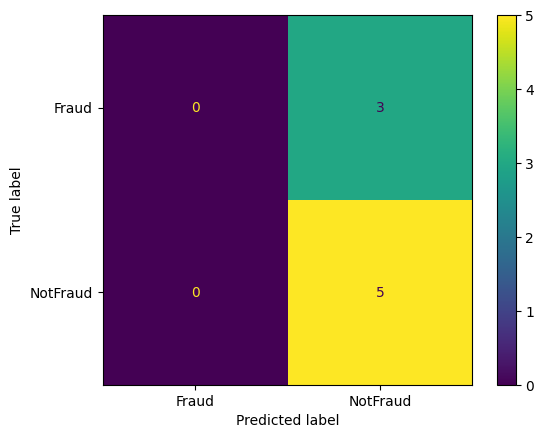

In [ ]:
plot_confusion_matrix(model,expected,predict)

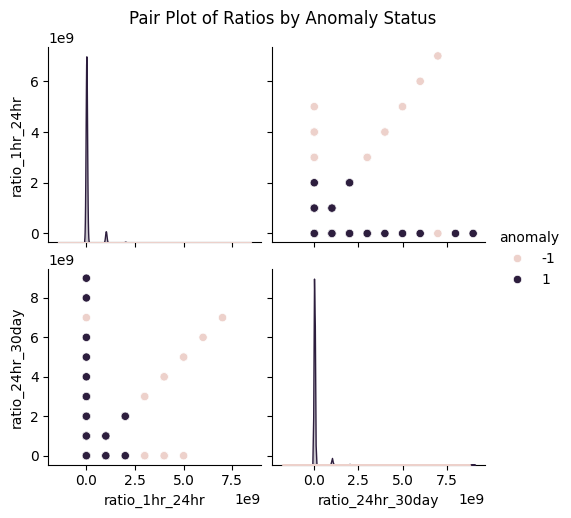

In [ ]:
# df1 contains the ratio features and the 'anomaly' column
sns.pairplot(train_df, vars=['ratio_1hr_24hr', 'ratio_24hr_30day'], hue='anomaly', diag_kind='kde')
plt.suptitle('Pair Plot of Ratios by Anomaly Status', y=1.02) # Adjust suptitle position
plt.show()

In [ ]:
train_df[train_df['anomaly'] == -1][training_features].describe()

,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,ratio_1hr_24hr,ratio_24hr_30day
count,110.000000,110.000000,110.000000,1.100000e+02,1.100000e+02
mean,2.490909,0.263636,4.200000,2.309091e+09,5.818182e+08
std,1.011362,0.809091,5.121998,1.246981e+09,1.558533e+09
min,0.000000,0.000000,0.000000,0.000000e+00,6.666667e-02
25%,2.000000,0.000000,2.000000,2.000000e+09,5.000000e-01
50%,2.000000,0.000000,3.000000,2.000000e+09,7.083333e-01
75%,3.000000,0.000000,5.000000,3.000000e+09,1.000000e+00
max,7.000000,5.000000,30.000000,7.000000e+09,7.000000e+09


In [ ]:
train_df[train_df['anomaly'] == 1][training_features].describe()

,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,ratio_1hr_24hr,ratio_24hr_30day
count,15330.000000,15330.000000,15330.000000,1.533000e+04,1.533000e+04
mean,0.065492,0.050228,1.364971,6.307893e+07,4.161774e+07
std,0.260251,0.283649,2.346897,2.561785e+08,2.465031e+08
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
50%,0.000000,0.000000,1.000000,0.000000e+00,0.000000e+00
75%,0.000000,0.000000,2.000000,0.000000e+00,0.000000e+00
max,2.000000,10.000000,42.000000,2.000000e+09,9.000000e+09


### Test Dataset


In [ ]:
test_df = pd.read_csv('/content/drive/Shareddrives/transaction-training-set/dataset/activeusers_high_velocity_testdataset.xlsx.csv')

### Display Shape of test dataframe
This cell shows the number of rows and columns in the `test_df` DataFrame.
In the test dataset the ratios are calculated by excel.

In [ ]:
test_df.shape

(207, 10)

This cell shows the number of users in the `test_df` DataFrame.

In [ ]:
test_df['User Id'].nunique()

19

In [ ]:
test_df_scaled = test_df.copy()

### Predictions on Test Data
This cell uses the scaled Isolation Forest model (`model1`) to make predictions on the test dataset.

In [ ]:
test_df_scaled[ratio_features] = scaler.transform(test_df[ratio_features])
predictions = model.predict(test_df_scaled[training_features])
predictions

array([ 1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1,
       -1, -1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1, -1, -1, -1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,  1,
        1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,
       -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1, -1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1, -1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1])

In [ ]:
pd.Series(predictions).value_counts()

,count
1,149
-1,58


In [ ]:
test_df.to_csv('testdata_model_pred.csv', index = False)

In [ ]:
test_df[test_df['Prediction'] == 1].describe()

,current_txn_amount,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,ratio_1hr_24hr,ratio_24hr_30day,Prediction
count,78.0,78.000000,78.000000,78.00000,78.000000,78.000000,78.0
mean,1000.0,0.192308,3.243590,5.75641,0.052605,0.520941,1.0
std,0.0,0.396664,2.968168,4.61276,0.150239,0.324298,0.0
min,1000.0,0.000000,0.000000,0.00000,0.000000,0.000000,1.0
25%,1000.0,0.000000,1.000000,3.00000,0.000000,0.333333,1.0
50%,1000.0,0.000000,3.000000,5.00000,0.000000,0.519231,1.0
75%,1000.0,0.000000,5.000000,8.00000,0.000000,0.800000,1.0
max,1000.0,1.000000,12.000000,32.00000,1.000000,1.000000,1.0


In [ ]:
test_df[test_df['Prediction'] == -1].describe()

,current_txn_amount,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,ratio_1hr_24hr,ratio_24hr_30day,Prediction
count,129.0,129.000000,129.000000,129.000000,129.000000,129.000000,129.0
mean,1000.0,2.868217,7.023256,12.658915,0.515963,0.680904,-1.0
std,0.0,1.724728,3.939910,10.420455,0.319402,0.270618,0.0
min,1000.0,0.000000,1.000000,1.000000,0.000000,0.060606,-1.0
25%,1000.0,1.000000,4.000000,6.000000,0.294118,0.555556,-1.0
50%,1000.0,3.000000,7.000000,10.000000,0.454545,0.750000,-1.0
75%,1000.0,4.000000,10.000000,14.000000,0.800000,0.888889,-1.0
max,1000.0,7.000000,17.000000,46.000000,1.000000,1.000000,-1.0


### Evaluation of Predicted Results

1.   This cell calls the plot_confusion_matrix function to visualize the performance of the Isolation Forest model (`model1`) on the test dataset.
2.   From the confusion matrix, it can be observed that out of 129 actual fraud records, the model correctly identified 58 as fraud, while 71 fraud cases were misclassified. Additionally, the model correctly classified all 78 non-fraud records, indicating no false positives in the test dataset.



Accuracy: 0.6570048309178744
Precision: 0.5234899328859061
Recall: 1.0
f1 score: 0.6872246696035242


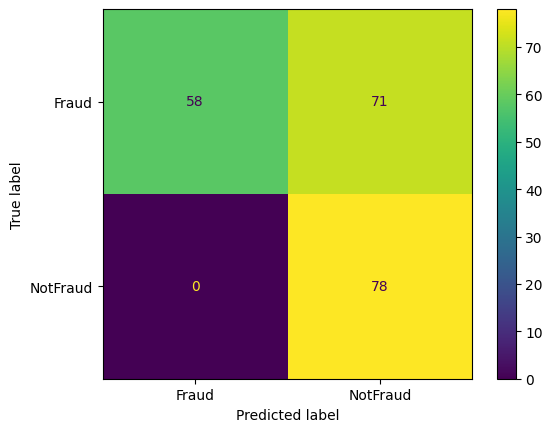

In [ ]:
plot_confusion_matrix(model,test_df['Prediction'],predictions)

Loaded the model and MinMax scaler

In [ ]:
# Load model
with open("scaledmodel_con0.001_activerecords.pkl", "rb") as f:
    model = pickle.load(f)

# Load scaler
with open("ratio_minmax_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

### Test Dataset

In [ ]:
test_df1 = pd.read_csv("/content/drive/Shareddrives/transaction-training-set/dataset/activeusers_high_velocity_testdataset.xlsx.csv")

Calculating (`ratio_features`) for the test dataset (`test_df1`)

In [ ]:
test_df1['ratio_1hr_24hr'] = test_df1['last_1hour_count'] / (test_df1['last_24hour_count_shifted'] + 1e-9)
test_df1['ratio_24hr_30day'] = test_df1['last_24hour_count_shifted'] / (test_df1['last_30days_count_shifted'] + 1e-9)

In [ ]:
test_df1[ratio_features] = scaler.transform(test_df1[ratio_features])

In [ ]:
data = test_df1[training_features]
predict = model.predict(data)
predict

array([ 1,  1,  1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
       -1, -1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
       -1, -1, -1, -1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1, -1,
       -1, -1,  1])

In [ ]:
pd.Series(predict).value_counts()

,count
1,157
-1,50


### Evaluation of Predicted Results

1.   This cell calls the plot_confusion_matrix function to visualize the performance of the Isolation Forest model (`model1`) on the test dataset.
2.   From the confusion matrix, it can be observed that out of 129 actual fraud records, the model correctly identified 50 as fraud, while 79 fraud cases were misclassified.

Accuracy: 0.6183574879227053
Precision: 0.4968152866242038
Recall: 1.0
f1 score: 0.6638297872340425


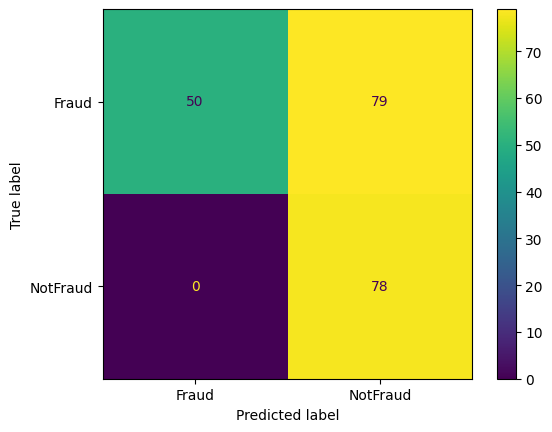

In [ ]:
plot_confusion_matrix(model,test_df1['Prediction'],predict)

In [ ]:
test_df1[test_df1['Prediction'] == 1].describe()

,current_txn_amount,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,Prediction,ratio_1hr_24hr,ratio_24hr_30day
count,78.0,78.000000,78.000000,78.00000,78.0,7.800000e+01,7.800000e+01
mean,1000.0,0.192308,3.243590,5.75641,1.0,7.515038e-12,5.788235e-11
std,0.0,0.396664,2.968168,4.61276,0.0,2.146265e-11,3.603315e-11
min,1000.0,0.000000,0.000000,0.00000,1.0,0.000000e+00,0.000000e+00
25%,1000.0,0.000000,1.000000,3.00000,1.0,0.000000e+00,3.703704e-11
50%,1000.0,0.000000,3.000000,5.00000,1.0,0.000000e+00,5.769231e-11
75%,1000.0,0.000000,5.000000,8.00000,1.0,0.000000e+00,8.888889e-11
max,1000.0,1.000000,12.000000,32.00000,1.0,1.428571e-10,1.111111e-10


In [ ]:
test_df1[test_df1['Prediction'] == -1].describe()

,current_txn_amount,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,Prediction,ratio_1hr_24hr,ratio_24hr_30day
count,129.0,129.000000,129.000000,129.000000,129.0,1.290000e+02,1.290000e+02
mean,1000.0,2.868217,7.023256,12.658915,-1.0,7.370894e-11,7.565601e-11
std,0.0,1.724728,3.939910,10.420455,0.0,4.562882e-11,3.006866e-11
min,1000.0,0.000000,1.000000,1.000000,-1.0,0.000000e+00,6.734007e-12
25%,1000.0,1.000000,4.000000,6.000000,-1.0,4.201681e-11,6.172840e-11
50%,1000.0,3.000000,7.000000,10.000000,-1.0,6.493506e-11,8.333333e-11
75%,1000.0,4.000000,10.000000,14.000000,-1.0,1.142857e-10,9.876543e-11
max,1000.0,7.000000,17.000000,46.000000,-1.0,1.428571e-10,1.111111e-10


In [ ]:
test_df2 = pd.read_csv("/content/HV_testdata_new_logic.csv")

In [ ]:
test_df2['ratio_1hr_24hr'] = test_df2['last_1hour_count'] / (test_df2['last_24hour_count_shifted'] + 1e-9)
test_df2['ratio_24hr_30day'] = test_df2['last_24hour_count'] / (test_df2['last_30days_count_shifted'] + 1e-9)

In [ ]:
test_df2[ratio_features] = scaler.transform(test_df2[ratio_features])

In [ ]:
data = test_df2[training_features]
predict1 = model.predict(data)
predict1

array([ 1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1,
       -1, -1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1, -1, -1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1, -1, -1, -1, -1, -1, -1,  1,  1,  1, -1, -1,
       -1,  1,  1,  1,  1,  1,  1, -1, -1, -1, -1,  1,  1,  1, -1, -1,  1,
       -1, -1,  1,  1, -1, -1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,
       -1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,
       -1, -1, -1, -1, -1, -1, -1, -1, -1,  1,  1,  1, -1, -1, -1, -1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1])

In [ ]:
pd.Series(predict1).value_counts()

,count
1,141
-1,66


Accuracy: 0.43478260869565216
Precision: 0.3617021276595745
Recall: 0.6538461538461539
f1 score: 0.4657534246575342


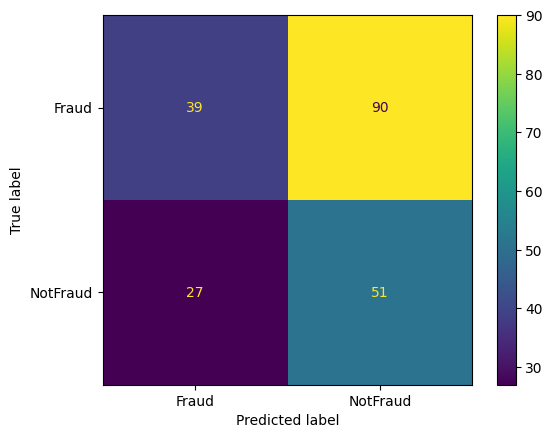

In [ ]:
plot_confusion_matrix(model,test_df1['Prediction'],predict1)

In [ ]:
test_df2[test_df2['Prediction'] == 1].describe()

,current_txn_amount,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,Unnamed: 7,Unnamed: 8,last_24hour_count,Prediction,ratio_1hr_24hr,ratio_24hr_30day
count,60.0,60.000000,60.000000,60.000000,0.0,0.0,60.000000,60.0,6.000000e+01,60.000000
mean,1000.0,0.366667,0.883333,0.733333,NaN,NaN,1.250000,1.0,2.619048e-02,0.075926
std,0.0,0.636906,1.180228,1.560820,NaN,NaN,1.491501,0.0,5.574356e-02,0.085558
min,1000.0,0.000000,0.000000,0.000000,NaN,NaN,0.000000,1.0,0.000000e+00,0.000000
25%,1000.0,0.000000,0.000000,0.000000,NaN,NaN,0.000000,1.0,0.000000e+00,0.000000
50%,1000.0,0.000000,0.000000,0.000000,NaN,NaN,1.000000,1.0,0.000000e+00,0.055556
75%,1000.0,1.000000,2.000000,0.000000,NaN,NaN,2.000000,1.0,8.035714e-11,0.111111
max,1000.0,3.000000,4.000000,4.000000,NaN,NaN,7.000000,1.0,1.428571e-01,0.222222


In [ ]:
test_df2[test_df2['Prediction'] == -1].describe()

,current_txn_amount,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,Unnamed: 7,Unnamed: 8,last_24hour_count,Prediction,ratio_1hr_24hr,ratio_24hr_30day
count,147.0,147.000000,147.000000,147.000000,0.0,0.0,147.000000,147.0,1.470000e+02,1.470000e+02
mean,1000.0,2.224490,4.734694,0.108844,NaN,NaN,6.959184,-1.0,8.843537e-02,7.619048e-01
std,0.0,1.893738,3.454849,0.653015,NaN,NaN,3.576708,0.0,2.070422e-01,4.118571e-01
min,1000.0,0.000000,0.000000,0.000000,NaN,NaN,2.000000,-1.0,0.000000e+00,5.555556e-11
25%,1000.0,1.000000,2.000000,0.000000,NaN,NaN,4.000000,-1.0,1.363636e-11,4.444444e-01
50%,1000.0,2.000000,4.000000,0.000000,NaN,NaN,6.000000,-1.0,5.714286e-11,6.666667e-01
75%,1000.0,3.500000,7.000000,0.000000,NaN,NaN,9.000000,-1.0,2.142857e-10,1.000000e+00
max,1000.0,7.000000,14.000000,4.000000,NaN,NaN,17.000000,-1.0,1.000000e+00,1.888889e+00


### Preparation of TestDataset


### Filter Transactions Recorded from 2018 to 2019
This cell creates a new DataFrame `df_filtered` containing only transactions that recorded from the year 2018 to 2019.

In [ ]:
df_filtered = df[
    (df['INITIATED_AT'] >= '2018-01-01') &
    (df['INITIATED_AT'] <= '2019-12-31')
].copy()
df_filtered

,TRANSACTION_KEY,ID,DOCUMENT_NUMBER,TRANSACTION_TYPE,PAYMENT_STRUCTURE_KEY,DEVICE_ID,SENDER_COUNTRY_KEY,SENDER_CURRENCY_KEY,SENDER_KEY,SENDER_ACCOUNT_KEY,...,EXCHANGE_RATE,TOTAL_FEES_ADDED,TOTAL_FEES_DEDUCTED,PAYMENT_FEE_ADDED,PAYOUT_FEE_ADDED,DELIVERY_SPEED_FEE_ADDED,INITIATED_AT,STATUS,USER_ID,TRANSACTION_COMPLETED_AT
1,4339531,26912,TR-90009133-0006,ACH_TRANSFER,NaN,NaN,102,102,133480,5332,...,108.15,NaN,NaN,0.0,NaN,NaN,2018-06-28 05:11:50+00:00,DELIVERED,67f131516b43913e05bc2294,2018-07-03T02:52:47
3,4334133,21422,TR-90001974-0027,ACH_TRANSFER,NaN,NaN,102,102,134648,2265,...,101.33,NaN,NaN,0.0,NaN,NaN,2018-02-15 03:55:23+00:00,DELIVERED,67f137f16b43913e05bc3bb2,2018-03-07T02:58:06
5,4206273,65870,MC-90003219-0026-R,ACH_TRANSFER,NaN,NaN,102,102,127427,18454,...,117.23,NaN,NaN,0.0,NaN,NaN,2018-10-11 20:46:34+00:00,REFUNDED_CANCELED,67f0f7b16b43913e05bbe555,2018-10-16T03:16:27
9,4217098,84314,MC-90005866-0004,ACH_TRANSFER,NaN,NaN,102,102,126937,22976,...,100.95,NaN,NaN,0.0,NaN,NaN,2018-02-16 17:03:20+00:00,DELIVERED,67f0f5306b43913e05bbd8f4,2018-02-23T18:05:37
14,4170264,36073,TR-90010824-0001,ACH_TRANSFER,NaN,NaN,102,102,133157,6185,...,112.50,NaN,NaN,0.0,NaN,NaN,2019-02-12 04:01:56+00:00,DELIVERED,67f12eac6b43913e05bc1779,2019-02-17T20:25:59
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
177007,4195907,45530,TR-90003645-0069,ACH_TRANSFER,NaN,NaN,102,102,87604,3324,...,112.40,NaN,NaN,0.0,NaN,NaN,2019-09-15 12:59:52+00:00,DELIVERED,3645,2019-09-17T03:16:29
177015,4341440,28853,TR-90005541-0020,ACH_TRANSFER,NaN,NaN,102,102,134070,4139,...,109.50,NaN,NaN,0.0,NaN,NaN,2018-08-16 02:04:31+00:00,DELIVERED,67f1345f9674261dc6955614,2018-08-21T13:00:33
177017,4207866,77033,MC-90006649-0003,ACH_TRANSFER,NaN,NaN,102,102,119500,21924,...,108.40,NaN,NaN,0.0,NaN,NaN,2018-06-29 23:36:20+00:00,DELIVERED,67f0de0b6b43913e05bba097,2018-07-05T18:14:57
177018,4340898,28302,TR-90008669-0003,ACH_TRANSFER,NaN,NaN,102,102,133579,4990,...,108.30,NaN,NaN,0.0,NaN,NaN,2018-08-02 05:48:23+00:00,DELIVERED,67f131b96b43913e05bc25f8,2018-08-07T13:57:59


In [ ]:
df_filtered.to_csv('txns_between_2018_2019.csv', index = False)

### Display DataFrame Shape
This cell shows the number of rows and columns in the `df_filtered` DataFrame.

In [ ]:
df_filtered.shape

(46009, 29)

### Display Users count in DataFrame
This cell shows the number of unique users in the `df_filtered` DataFrame.

In [ ]:
df_filtered['USER_ID'].nunique()

5575

### Display Legacy and New Infra Users count in DataFrame
This cell shows the number of Legacy users and New Infra users in the `df_filtered` DataFrame.

In [ ]:
df_filtered['ID'] = df_filtered['ID'].astype(str)
legacy_users = df_filtered[df_filtered['ID'].str.isdigit()]['ID'].nunique()
new_infra = df_filtered[~df_filtered['ID'].str.isdigit()]['ID'].nunique()
print(legacy_users)
print(new_infra)

46009
0


In [ ]:
high_velocity_train_df = pd.read_csv('/content/training_dataset_high_velocity_users.csv', low_memory = False)

In [ ]:
user_counts = high_velocity_train_df['USER_ID'].value_counts()
user_counts

,count
USER_ID,
67f138ec6b43913e05bc414b,94
67f0e81b9674261dc694e38c,91
67e1058712a92f3e5a126465,88
67f103039674261dc695134b,69
67f11d566b43913e05bbfeb9,68
...,...
67f0fd259674261dc6950435,1
67f114306b43913e05bbef06,1
67f0ecf76b43913e05bbb9d5,1


In [ ]:
top_users = user_counts.sort_values(ascending=False)
top_10_users = top_users.head(10)
top_10_users

,count
USER_ID,
67f138ec6b43913e05bc414b,94
67f0e81b9674261dc694e38c,91
67e1058712a92f3e5a126465,88
67f103039674261dc695134b,69
67f11d566b43913e05bbfeb9,68
67ec0c4431a08643d210dc9d,64
67f106d69674261dc6951d08,60
67f0e5c66b43913e05bbaecc,57
67f0fbee9674261dc69501fb,52


In [ ]:
high_velocity_train_df.loc[high_velocity_train_df['USER_ID'] == "67f138ec6b43913e05bc414b", 'STATUS'].value_counts()

,count
STATUS,
COMPLETED,70
PENDING,15
DELIVERED,8
INITIATED,1


In [ ]:
target_status = ['CANCELED', 'REFUNDED', 'CLEARING_FAILED', 'RETURNED', 'REFUNDED_CANCELED']

In [ ]:
users_with_target_status = high_velocity_train_df.loc[
    high_velocity_train_df['STATUS'].isin(target_status),
    'USER_ID'
].unique()
users_with_target_status

array(['67f0f76b6b43913e05bbe25f', '67f0e61d6b43913e05bbb25e',
       '67f11b336b43913e05bbfa80', '67e78c7c336a491f6c3cd043',
       '67f0ef296b43913e05bbc10b', '67f0e97f9674261dc694ea47',
       '67f1090b9674261dc695253f', '67f12ad56b43913e05bc12e3',
       '67f0da536b43913e05bb9793', '67f0e70f9674261dc694d830',
       '67f0ecdd6b43913e05bbb882', '67f0e6bc9674261dc694d464',
       '67f0dde26b43913e05bb9e87', '67f0f5bd6b43913e05bbdadd',
       '67e80f266e1db606cdd20e51', '67f0de026b43913e05bba012',
       '67f1034e9674261dc6951621', '67e1058712a92f3e5a126465',
       '67f0de006b43913e05bb9fff', '68e186ec0b48414741addefd',
       '67f0ef6d6b43913e05bbc3b5', '67f0e81b9674261dc694e38c',
       '67f1017a9674261dc6950974', '67f0df4d9674261dc694cd13',
       '6892fde7faf98a32d46c22d4', '67f0e58c6b43913e05bbad63',
       '67f10f2e9674261dc6953e2d', '67f113e16b43913e05bbec7f',
       '67f0f2846b43913e05bbd2c1', '67f11b526b43913e05bbfb8a',
       '67f113dc6b43913e05bbec49', '6892e9fab2e6282ecaf

In [ ]:
user_target_counts = (
    high_velocity_train_df[
        high_velocity_train_df['STATUS'].isin(target_status)
    ]
    .groupby('USER_ID')
    .size()
    .sort_values(ascending=False)
)
user_target_counts

,0
USER_ID,
68e186ec0b48414741addefd,5
67f0f2846b43913e05bbd2c1,4
6882938f52da24620f320de6,4
67f0da576b43913e05bb97b8,3
67f0e97f9674261dc694ea47,3
...,...
67f131516b43913e05bc2294,1
6892e9fab2e6282ecaf76186,1
686c9dfaa6e803204e968cc5,1


In [ ]:
total_users = high_velocity_train_df['USER_ID'].nunique()
users_with_target = high_velocity_train_df.loc[
    high_velocity_train_df['STATUS'].isin(target_status),
    'USER_ID'
].nunique()
users_without_target = total_users - users_with_target
print("Total Users:", total_users)
print("Users with ≥1 target status txn:", users_with_target)
print("Users with 0 target status txn:", users_without_target)

Total Users: 1707
Users with ≥1 target status txn: 137
Users with 0 target status txn: 1570


In [ ]:
txn_df = pd.read_csv('/content/txns_between_2018_2019.csv', low_memory = False)

### Merging the users
This cell shows the merging of the `high_velocity_train_df` DataFrame with the `txn_df` DataFrame to get the records of only the userids which are present in both the DataFrames, but in the `final_df` DataFrame the problem is when merging for example if a userid is matching with both high_velocity_train_df and txn_df DataFrames and the records count of that userid in high_velocity_train_df DataFrame is 3 and the records count of that userid in txn_df DataFrame is 12 then in the final_df the total number of records of that userid is 36 records that mean it is considering 3*12 records for that user.

In [ ]:
final_df = high_velocity_train_df.merge(txn_df, on = 'USER_ID', how = 'inner')
final_df

,TRANSACTION_KEY_x,ID_x,DOCUMENT_NUMBER_x,TRANSACTION_TYPE_x,PAYMENT_STRUCTURE_KEY_x,DEVICE_ID_x,SENDER_COUNTRY_KEY_x,SENDER_CURRENCY_KEY_x,SENDER_KEY_x,SENDER_ACCOUNT_KEY_x,...,TOTAL_CREDIT_AMOUNT_y,EXCHANGE_RATE_y,TOTAL_FEES_ADDED_y,TOTAL_FEES_DEDUCTED_y,PAYMENT_FEE_ADDED_y,PAYOUT_FEE_ADDED_y,DELIVERY_SPEED_FEE_ADDED_y,INITIATED_AT_y,STATUS_y,TRANSACTION_COMPLETED_AT_y
0,2140127,69265cb5ef7b8d42c02f1967,900011135,STANDARD,2.0,f6d3444d-4411-4fa2-ab35-6422bf2dd7ee,102,101,120642,84238,...,108550.0,108.55,NaN,NaN,0.0,NaN,NaN,2019-07-10 02:14:20+00:00,DELIVERED,2019-07-22T16:20:05
1,2140127,69265cb5ef7b8d42c02f1967,900011135,STANDARD,2.0,f6d3444d-4411-4fa2-ab35-6422bf2dd7ee,102,101,120642,84238,...,226260.0,113.13,NaN,NaN,0.0,NaN,NaN,2019-02-06 16:50:18+00:00,DELIVERED,2019-02-14T21:12:08
2,2140127,69265cb5ef7b8d42c02f1967,900011135,STANDARD,2.0,f6d3444d-4411-4fa2-ab35-6422bf2dd7ee,102,101,120642,84238,...,219120.0,109.56,NaN,NaN,0.0,NaN,NaN,2019-04-19 15:01:27+00:00,DELIVERED,2019-04-25T17:58:29
3,2140127,69265cb5ef7b8d42c02f1967,900011135,STANDARD,2.0,f6d3444d-4411-4fa2-ab35-6422bf2dd7ee,102,101,120642,84238,...,218300.0,109.15,NaN,NaN,0.0,NaN,NaN,2019-03-18 00:38:52+00:00,DELIVERED,2019-03-26T16:49:41
4,2140127,69265cb5ef7b8d42c02f1967,900011135,STANDARD,2.0,f6d3444d-4411-4fa2-ab35-6422bf2dd7ee,102,101,120642,84238,...,224020.0,112.01,NaN,NaN,0.0,NaN,NaN,2019-03-03 14:24:42+00:00,DELIVERED,2019-03-11T22:49:38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
124694,4325312,169535,XU-90000098-0120,ACH_TRANSFER,NaN,NaN,102,102,119005,48391,...,256750.0,102.70,NaN,NaN,0.0,NaN,NaN,2018-04-06 15:47:01+00:00,REFUNDED_CANCELED,2018-04-06T18:26:20
124695,4325312,169535,XU-90000098-0120,ACH_TRANSFER,NaN,NaN,102,102,119005,48391,...,110700.0,110.70,NaN,NaN,0.0,NaN,NaN,2018-08-27 15:32:41+00:00,DELIVERED,2018-09-06T18:20:05
124696,4325312,169535,XU-90000098-0120,ACH_TRANSFER,NaN,NaN,102,102,119005,48391,...,570250.0,114.05,NaN,NaN,0.0,NaN,NaN,2018-11-14 16:18:28+00:00,DELIVERED,2018-11-26T14:10:40
124697,4325312,169535,XU-90000098-0120,ACH_TRANSFER,NaN,NaN,102,102,119005,48391,...,104600.0,104.60,NaN,NaN,0.0,NaN,NaN,2018-04-23 15:54:05+00:00,DELIVERED,2018-05-03T01:01:07


### Display DataFrame Shape
This cell shows the number of rows and columns in the `final_df` DataFrame.

In [ ]:
final_df.shape

(124699, 57)

### Display Users count in DataFrame
This cell shows the number of unique users in the `final_df` DataFrame.

In [ ]:
final_df['USER_ID'].nunique()

1067

To check if all the user ids in the `final_df` DataFrame matches with the `high_velocity_train_df` DataFrame.

In [ ]:
not_matching = final_df[~final_df["USER_ID"].isin(high_velocity_train_df["USER_ID"])]
if not_matching.empty:
    print("All user_ids match")
else:
    print("Mismatched user_ids found")
    print(not_matching["USER_ID"].unique())

All user_ids match


### Filtering the User IDs
To resolve the duplication issue caused by the merge operation (where matching user IDs resulted in a Cartesian product of records), the `.isin()` method was used to filter the DataFrame and retain only the relevant user IDs, ensuring the correct record count without inflating the number of rows.



In [ ]:
filtered_txn_df = txn_df[txn_df['USER_ID'].isin(high_velocity_train_df['USER_ID'])]

In [ ]:
filtered_txn_df

,TRANSACTION_KEY,ID,DOCUMENT_NUMBER,TRANSACTION_TYPE,PAYMENT_STRUCTURE_KEY,DEVICE_ID,SENDER_COUNTRY_KEY,SENDER_CURRENCY_KEY,SENDER_KEY,SENDER_ACCOUNT_KEY,...,EXCHANGE_RATE,TOTAL_FEES_ADDED,TOTAL_FEES_DEDUCTED,PAYMENT_FEE_ADDED,PAYOUT_FEE_ADDED,DELIVERY_SPEED_FEE_ADDED,INITIATED_AT,STATUS,USER_ID,TRANSACTION_COMPLETED_AT
0,4339531,26912,TR-90009133-0006,ACH_TRANSFER,NaN,NaN,102,102,133480,5332,...,108.15,NaN,NaN,0.0,NaN,NaN,2018-06-28 05:11:50+00:00,DELIVERED,67f131516b43913e05bc2294,2018-07-03T02:52:47
2,4206273,65870,MC-90003219-0026-R,ACH_TRANSFER,NaN,NaN,102,102,127427,18454,...,117.23,NaN,NaN,0.0,NaN,NaN,2018-10-11 20:46:34+00:00,REFUNDED_CANCELED,67f0f7b16b43913e05bbe555,2018-10-16T03:16:27
3,4217098,84314,MC-90005866-0004,ACH_TRANSFER,NaN,NaN,102,102,126937,22976,...,100.95,NaN,NaN,0.0,NaN,NaN,2018-02-16 17:03:20+00:00,DELIVERED,67f0f5306b43913e05bbd8f4,2018-02-23T18:05:37
5,4178262,42146,TR-90002910-0046,ACH_TRANSFER,NaN,NaN,102,102,142021,2335,...,108.92,NaN,NaN,10.0,NaN,NaN,2019-06-28 15:29:38+00:00,DELIVERED,67f0e6e89674261dc694d691,2019-07-01T20:18:46
8,4177136,41427,TR-90008405-0037,ACH_TRANSFER,NaN,NaN,102,102,120541,6481,...,109.49,NaN,NaN,0.0,NaN,NaN,2019-06-10 12:28:58+00:00,DELIVERED,67f0e5f56b43913e05bbb09e,2019-06-17T09:44:50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45993,4166948,34300,TR-90006265-0026,ACH_TRANSFER,NaN,NaN,102,102,129507,3747,...,110.57,NaN,NaN,0.0,NaN,NaN,2018-12-27 03:13:57+00:00,DELIVERED,67f10a729674261dc6952b2a,2019-01-01T10:02:54
46001,4166286,33234,TR-90000142-0015,ACH_TRANSFER,NaN,NaN,102,102,128110,1990,...,111.67,NaN,NaN,0.0,NaN,NaN,2018-11-23 18:04:27+00:00,DELIVERED,67f0fbff9674261dc69502b8,2018-12-03T13:45:38
46002,4232710,78907,MC-90004299-0063,ACH_TRANSFER,NaN,NaN,102,102,120057,22203,...,111.40,NaN,NaN,0.0,NaN,NaN,2018-11-27 04:31:18+00:00,DELIVERED,67f0dfbd9674261dc694d23c,2018-12-21T09:42:16
46006,4207866,77033,MC-90006649-0003,ACH_TRANSFER,NaN,NaN,102,102,119500,21924,...,108.40,NaN,NaN,0.0,NaN,NaN,2018-06-29 23:36:20+00:00,DELIVERED,67f0de0b6b43913e05bba097,2018-07-05T18:14:57


### Display DataFrame Shape
This cell shows the number of rows and columns in the `filtered_txn_df` DataFrame.

In [ ]:
filtered_txn_df.shape

(13177, 29)

### Display Users count in DataFrame
This cell shows the number of unique users in the `filtered_txn_df` DataFrame.

In [ ]:
filtered_txn_df['USER_ID'].nunique()

1067

To check if all the user ids in the `filtered_txn_df` DataFrame matches with the `high_velocity_train_df` DataFrame.

In [ ]:
not_matching = filtered_txn_df[~filtered_txn_df["USER_ID"].isin(high_velocity_train_df["USER_ID"])]
if not_matching.empty:
    print("All user_ids match")
else:
    print("Mismatched user_ids found")
    print(not_matching["USER_ID"].unique())

All user_ids match


The initiated_at timestamps in the `filtered_txn_df` DataFrame were modified by updating the year from 2018 to 2026 and from 2019 to 2025.

In [ ]:
filtered_txn_df = filtered_txn_df.copy()
filtered_txn_df['INITIATED_AT'] = pd.to_datetime(filtered_txn_df['INITIATED_AT'], format="ISO8601", utc=True)
filtered_txn_df.loc[filtered_txn_df['INITIATED_AT'].dt.year == 2018, 'INITIATED_AT'] += pd.DateOffset(years=8)
filtered_txn_df.loc[filtered_txn_df['INITIATED_AT'].dt.year == 2019, 'INITIATED_AT'] += pd.DateOffset(years=6)
filtered_txn_df.to_csv('dataset.csv', index = False)

### Feature Engineering for High Velocity Transactions test data


In [ ]:
high_velocity_test_df = filtered_txn_df.copy()
high_velocity_test_df['INITIATED_AT'] = pd.to_datetime(high_velocity_test_df['INITIATED_AT'], format="ISO8601", utc=True)

In [ ]:
# 1. Pre-processing: Convert to datetime and sort
# Sorting is critical so the .values assignment aligns correctly

high_velocity_test_df = high_velocity_test_df.sort_values(by=['USER_ID', 'INITIATED_AT']).reset_index(drop=True)

# 2. Define the rolling windows for the raw counts
# We use a helper function or dictionary to keep the code clean
grouped = high_velocity_test_df.groupby('USER_ID')

# Calculation: Recent 1 Hour
# Window: [T, T - 1h]
high_velocity_test_df['cnt_1h'] = grouped.rolling('1h', on='INITIATED_AT')['TRANSACTION_KEY'].count().values - 1

# Calculation: Total 25 Hours (to derive the 24h block ending 1h ago)
# Window: [T, T - 25h]
high_velocity_test_df['cnt_total_25h'] = grouped.rolling('25h', on='INITIATED_AT')['TRANSACTION_KEY'].count().values - 1

high_velocity_test_df['last_24hour_count'] = grouped.rolling('24h', on='INITIATED_AT')['TRANSACTION_KEY'].count().values - 1

# Calculation: Total 31 Days + 1 Hour (to derive the 30d block ending 25h ago)
# Window: [T, T - 745h]
high_velocity_test_df['cnt_total_31d'] = grouped.rolling('31D', on='INITIATED_AT')['TRANSACTION_KEY'].count().values - 1

# 3. Final Feature Transformation (Isolating the specific blocks)
# Feature 1: Current activity
high_velocity_test_df['last_1hour_count'] = high_velocity_test_df['cnt_1h']

# Feature 2: 24h window ending 1 hour ago (Total 25h - Recent 1h)
high_velocity_test_df['last_24hour_count_shifted'] = high_velocity_test_df['cnt_total_25h'] - high_velocity_test_df['cnt_1h']

# Feature 3: 30d window ending 25 hours ago (Total 31d 1h - Recent 25h)
high_velocity_test_df['last_30days_count_shifted'] = high_velocity_test_df['cnt_total_31d'] - high_velocity_test_df['last_24hour_count']

# 4. Clean up intermediate columns
high_velocity_test_df.drop(columns=['cnt_total_25h', 'cnt_total_31d'], inplace=True)

# Display the result
print(high_velocity_test_df[['USER_ID', 'INITIATED_AT', 'last_1hour_count', 'last_24hour_count_shifted', 'last_30days_count_shifted']].tail())

                        USER_ID              INITIATED_AT  last_1hour_count  \
13172  67f13a4a9674261dc69563eb 2026-07-24 16:41:09+00:00               0.0   
13173  67f13a4a9674261dc69563eb 2026-09-06 01:46:20+00:00               0.0   
13174  67f13a4a9674261dc69563eb 2026-12-21 17:45:07+00:00               0.0   
13175  67f13a4a9674261dc69563eb 2026-12-21 17:51:15+00:00               1.0   
13176  6829eb2fbaf7d85b2efd0af9 2025-02-06 03:07:45+00:00               0.0   

       last_24hour_count_shifted  last_30days_count_shifted  
13172                        0.0                        1.0  
13173                        0.0                        0.0  
13174                        0.0                        0.0  
13175                        0.0                        0.0  
13176                        0.0                        0.0  


In [ ]:
high_velocity_test_df['ratio_1hr_24hr'] = high_velocity_test_df['last_1hour_count'] / (high_velocity_test_df['last_24hour_count_shifted'] + 1e-9)
high_velocity_test_df['ratio_24hr_30day'] = high_velocity_test_df['last_24hour_count'] / (high_velocity_test_df['last_30days_count_shifted'] + 1e-9)

In [ ]:
high_velocity_test_df.to_csv('high_velocity_test_dataset.csv', index = False)

In [ ]:
high_velocity_test_df.shape

(13177, 36)

In [ ]:
high_velocity_test_df['USER_ID'].nunique()

1067

In [ ]:
not_matching = high_velocity_test_df[~high_velocity_test_df["USER_ID"].isin(high_velocity_train_df["USER_ID"])]
if not_matching.empty:
    print("All user_ids match")
else:
    print("Mismatched user_ids found")
    print(not_matching["USER_ID"].unique())

All user_ids match


In [ ]:
high_velocity_test_df[['last_1hour_count', 'last_24hour_count_shifted', 'last_30days_count_shifted', 'ratio_1hr_24hr', 'ratio_24hr_30day']].describe()

,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,ratio_1hr_24hr,ratio_24hr_30day
count,13177.000000,13177.000000,13177.000000,1.317700e+04,1.317700e+04
mean,0.107612,0.024968,0.820369,1.054868e+08,7.050163e+07
std,0.360189,0.184556,1.145190,3.567985e+08,2.997044e+08
min,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
25%,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
50%,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00
75%,0.000000,0.000000,1.000000,0.000000e+00,0.000000e+00
max,5.000000,4.000000,11.000000,5.000000e+09,5.000000e+09


In [ ]:
HV_test_df = pd.read_csv('/content/high_velocity_test_dataset (1).csv', low_memory = False)

In [ ]:
HV_test_df_scaled = HV_test_df.copy()

In [ ]:
with open("ratio_minmax_scaler.pkl", "rb") as f:
    scaler = pickle.load(f)

In [ ]:
scaler.data_min_
scaler.data_max_


array([7.e+09, 9.e+09])

In [ ]:
HV_test_df_scaled[ratio_features] = scaler.transform(HV_test_df[ratio_features])
predicted_HV = model.predict(HV_test_df_scaled[training_features])
predicted_HV

array([1, 1, 1, ..., 1, 1, 1])

In [ ]:
HV_test_df['model_prediction'] = predicted_HV

In [ ]:
pd.Series(predicted_HV).value_counts()

,count
1,13176
-1,1


Accuracy: 0.9998482203840025
Precision: 0.9999241044323012
Recall: 0.9999241044323012
f1 score: 0.9999241044323012


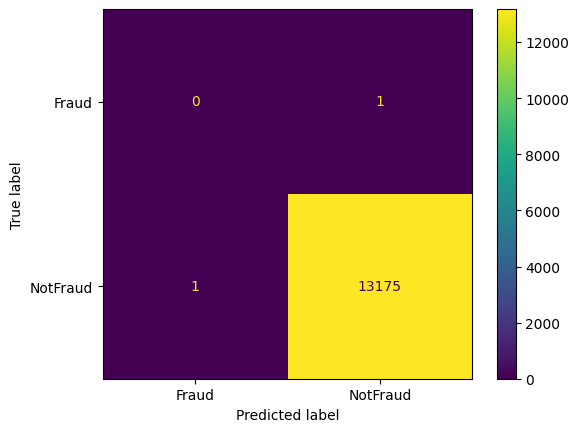

In [ ]:
plot_confusion_matrix(model,HV_test_df['Prediction'],predicted_HV)

In [ ]:
HV_test_df[HV_test_df['model_prediction'] == 1].describe()

,TRANSACTION_KEY,ID,PAYMENT_STRUCTURE_KEY,DEVICE_ID,SENDER_COUNTRY_KEY,SENDER_CURRENCY_KEY,SENDER_KEY,SENDER_ACCOUNT_KEY,SENDER_PAYMENT_INSTRUMENT_KEY,RECIPIENT_CURRENCY_KEY,...,DELIVERY_SPEED_FEE_ADDED,cnt_1h,last_24hour_count,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,ratio_1hr_24hr,ratio_24hr_30day,Prediction,model_prediction
count,1.317600e+04,13176.000000,0.0,0.0,13176.0,13176.0,13176.000000,13176.000000,0.0,0.0,...,0.0,13176.000000,13176.000000,13176.000000,13176.000000,13176.000000,1.317600e+04,1.317600e+04,13176.000000,13176.0
mean,4.235404e+06,45210.266469,NaN,NaN,102.0,102.0,127523.416439,7669.176988,NaN,NaN,...,NaN,0.107316,0.130920,0.107316,0.024970,0.820431,1.051913e+08,7.020340e+07,0.999848,1.0
std,7.009012e+04,21336.557711,NaN,NaN,0.0,0.0,7688.007648,7748.027843,NaN,NaN,...,NaN,0.358603,0.403322,0.358603,0.184563,1.145212,3.551951e+08,2.977540e+08,0.017424,0.0
min,4.164273e+06,19833.000000,NaN,NaN,102.0,102.0,118280.000000,644.000000,NaN,NaN,...,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,-1.000000,1.0
25%,4.175096e+06,30030.750000,NaN,NaN,102.0,102.0,121004.000000,2815.000000,NaN,NaN,...,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,1.0
50%,4.196428e+06,39368.500000,NaN,NaN,102.0,102.0,126523.000000,4518.000000,NaN,NaN,...,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,1.000000,1.0
75%,4.334424e+06,48228.500000,NaN,NaN,102.0,102.0,131320.000000,6533.000000,NaN,NaN,...,NaN,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000e+00,0.000000e+00,1.000000,1.0
max,4.344195e+06,104902.000000,NaN,NaN,102.0,102.0,145301.000000,26786.000000,NaN,NaN,...,NaN,5.000000,5.000000,5.000000,4.000000,11.000000,5.000000e+09,5.000000e+09,1.000000,1.0


In [ ]:
HV_test_df[HV_test_df['model_prediction'] == -1].describe()

,TRANSACTION_KEY,ID,PAYMENT_STRUCTURE_KEY,DEVICE_ID,SENDER_COUNTRY_KEY,SENDER_CURRENCY_KEY,SENDER_KEY,SENDER_ACCOUNT_KEY,SENDER_PAYMENT_INSTRUMENT_KEY,RECIPIENT_CURRENCY_KEY,...,DELIVERY_SPEED_FEE_ADDED,cnt_1h,last_24hour_count,last_1hour_count,last_24hour_count_shifted,last_30days_count_shifted,ratio_1hr_24hr,ratio_24hr_30day,Prediction,model_prediction
count,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,...,0.0,1.0,1.0,1.0,1.0,1.0,1.000000e+00,1.000000e+00,1.0,1.0
mean,4194435.0,49567.0,NaN,NaN,102.0,102.0,121792.0,7338.0,NaN,NaN,...,NaN,4.0,4.0,4.0,0.0,0.0,4.000000e+09,4.000000e+09,1.0,-1.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,4194435.0,49567.0,NaN,NaN,102.0,102.0,121792.0,7338.0,NaN,NaN,...,NaN,4.0,4.0,4.0,0.0,0.0,4.000000e+09,4.000000e+09,1.0,-1.0
25%,4194435.0,49567.0,NaN,NaN,102.0,102.0,121792.0,7338.0,NaN,NaN,...,NaN,4.0,4.0,4.0,0.0,0.0,4.000000e+09,4.000000e+09,1.0,-1.0
50%,4194435.0,49567.0,NaN,NaN,102.0,102.0,121792.0,7338.0,NaN,NaN,...,NaN,4.0,4.0,4.0,0.0,0.0,4.000000e+09,4.000000e+09,1.0,-1.0
75%,4194435.0,49567.0,NaN,NaN,102.0,102.0,121792.0,7338.0,NaN,NaN,...,NaN,4.0,4.0,4.0,0.0,0.0,4.000000e+09,4.000000e+09,1.0,-1.0
max,4194435.0,49567.0,NaN,NaN,102.0,102.0,121792.0,7338.0,NaN,NaN,...,NaN,4.0,4.0,4.0,0.0,0.0,4.000000e+09,4.000000e+09,1.0,-1.0


In [ ]:
HV_test_df.to_csv('HV_test_with_predictions.csv', index=False)